# Analise agregada dos deltas por estimulo emocional

Este notebook unifica o prompt vanilla (`Baseline`) com as abas `answersEP01` a `answersEP11`, salva o dataset agregado em CSV e gera os graficos comparativos.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "stimulus_answers").exists() else CURRENT_DIR.parent

STIMULUS_FILE = PROJECT_ROOT / "stimulus_answers" / "1_stimulus.xlsx"
VANILLA_FILE = PROJECT_ROOT / "original_answers" / "1_original.xlsx"
PLAIN_FILE = PROJECT_ROOT / "plain_answers" / "1_plain.xlsx"
OUTPUT_CSV = PROJECT_ROOT / "scripts" / "1_results_stimulus_aggregated.csv"

EP_SHEETS = [f"answersEP{i:02d}" for i in range(1, 12)]
EP_LABELS = [f"EP{i:02d}" for i in range(1, 12)]
REFERENCE_LABELS = ["Baseline", "Plain"]
PLOT_ORDER = [*REFERENCE_LABELS, *EP_LABELS]
GAIN_BASELINE_ORDER = ["Plain", *EP_LABELS]

QUESTION_CODE_PATTERN = r"(Q\d+)"
IGNORED_QUESTIONS = {"Q3", "Q4"}

COLORS = {
    "baseline": "#F97316",
    "plain": "#16A34A",
    "ep": "#2563EB",
    "purple": "#7E22CE",
    "negative": "#DC2626",
    "grid": "#E5E7EB",
    "text": "#111827",
}


In [2]:
def answer_key(value):
    if pd.isna(value):
        return "__NA__"
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value).strip()


def question_code_from_series(question_series):
    return question_series.astype("string").str.extract(QUESTION_CODE_PATTERN, expand=False)


def add_delta_absolute(frame):
    frame = frame.copy()
    frame["Percentage"] = pd.to_numeric(frame["Percentage"], errors="coerce")
    frame["Perc_Baseline_Numeric"] = pd.to_numeric(frame["Perc_Baseline"], errors="coerce")
    frame["Delta_Absolute"] = (frame["Percentage"] - frame["Perc_Baseline_Numeric"]).abs()
    return frame


def build_question_map(path):
    questions = pd.read_excel(path, sheet_name="Questions")["Question"].drop_duplicates().tolist()
    return {f"Q{i}": question for i, question in enumerate(questions, start=1)}


def load_control_answers(path, prompt_label, prompt_type, stimulus_label, question_map):
    control = pd.read_excel(path, sheet_name="Questions")
    reverse_question_map = {question: code for code, question in question_map.items()}

    control = control.rename(columns={"Question": "Question_Text"})
    control.insert(0, "Prompt", prompt_label)
    control.insert(1, "Prompt_Type", prompt_type)
    control.insert(2, "Sheet", "Questions")
    control.insert(3, "Stimulus", stimulus_label)
    control.insert(4, "Question_Code", control["Question_Text"].map(reverse_question_map))
    control["Question_Source"] = control["Question_Text"]
    control["Answer_Key"] = control["Answer"].map(answer_key)
    control = add_delta_absolute(control)
    return control


def load_stimulus_answers(path, sheets, question_map):
    frames = []

    for sheet in sheets:
        ep_number = int(sheet.replace("answersEP", ""))
        ep_label = f"EP{ep_number:02d}"
        stimulus_label = f"ep{ep_number:02d}"

        frame = pd.read_excel(path, sheet_name=sheet)
        frame = frame.rename(columns={"Question": "Question_Source"})
        frame.insert(0, "Prompt", ep_label)
        frame.insert(1, "Prompt_Type", "Stimulus")
        frame.insert(2, "Sheet", sheet)
        frame.insert(3, "Question_Code", question_code_from_series(frame["Question_Source"]))

        if "Stimulus" not in frame.columns:
            frame.insert(4, "Stimulus", stimulus_label)
        else:
            frame["Stimulus"] = frame["Stimulus"].fillna(stimulus_label).astype(str).str.lower()

        frame["Question_Text"] = frame["Question_Code"].map(question_map)
        frame["Answer_Key"] = frame["Answer"].map(answer_key)
        frame = add_delta_absolute(frame)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


question_map = build_question_map(VANILLA_FILE)
vanilla_answers = load_control_answers(VANILLA_FILE, "Baseline", "Baseline", "baseline", question_map)
plain_answers = load_control_answers(PLAIN_FILE, "Plain", "Plain", "plain", question_map)
stimulus_answers = load_stimulus_answers(STIMULUS_FILE, EP_SHEETS, question_map)

common_columns = [
    "Prompt",
    "Prompt_Type",
    "Sheet",
    "Stimulus",
    "Question_Code",
    "Question_Text",
    "Question_Source",
    "Answer",
    "Answer_Key",
    "Percentage",
    "Perc_Baseline",
    "Perc_Baseline_Numeric",
    "Delta_Absolute",
    "Population",
    "Type",
    "Options",
    "NA",
    "Study",
    "Delta_Baseline",
    "Absolute_Answers_GPT",
    "Perc_GPT",
    "Delta_GPT",
]

results_aggregated = pd.concat(
    [
        vanilla_answers[common_columns],
        plain_answers[common_columns],
        stimulus_answers[common_columns],
    ],
    ignore_index=True,
)

results_aggregated = results_aggregated[
    ~results_aggregated["Question_Code"].isin(IGNORED_QUESTIONS)
].copy()
results_aggregated = results_aggregated.dropna(subset=["Perc_Baseline_Numeric", "Delta_Absolute"])
results_aggregated["Prompt"] = pd.Categorical(results_aggregated["Prompt"], categories=PLOT_ORDER, ordered=True)
results_aggregated = results_aggregated.sort_values(["Prompt", "Question_Code", "Answer_Key"]).reset_index(drop=True)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
results_aggregated.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Dataset agregado salvo em: {OUTPUT_CSV}")
print(f"Dimensoes do dataset agregado: {results_aggregated.shape}")
display(results_aggregated.head())


Dataset agregado salvo em: C:\UTFPR\Engenharia software experimental\gpt-emotional-stimulus\scripts\1_results_stimulus_aggregated.csv
Dimensoes do dataset agregado: (260, 22)


,Prompt,Prompt_Type,Sheet,Stimulus,Question_Code,Question_Text,Question_Source,Answer,Answer_Key,Percentage,Perc_Baseline,Perc_Baseline_Numeric,Delta_Absolute,Population,Type,Options,NA,Study,Delta_Baseline,Absolute_Answers_GPT,Perc_GPT,Delta_GPT
0,Baseline,Baseline,Questions,baseline,Q1,How useful are bot recommendations as a PR aut...,How useful are bot recommendations as a PR aut...,1,1,5.5556,20,20.0000,14.4444,54,Likert,5,N,1,14.4444,NaN,0.0000,5.5556
1,Baseline,Baseline,Questions,baseline,Q1,How useful are bot recommendations as a PR aut...,How useful are bot recommendations as a PR aut...,2,2,5.5556,20,20.0000,14.4444,54,Likert,5,N,1,14.4444,NaN,0.0000,5.5556
2,Baseline,Baseline,Questions,baseline,Q1,How useful are bot recommendations as a PR aut...,How useful are bot recommendations as a PR aut...,3,3,22.2222,20,20.0000,2.2222,54,Likert,5,N,1,2.2222,NaN,0.0000,22.2222
3,Baseline,Baseline,Questions,baseline,Q1,How useful are bot recommendations as a PR aut...,How useful are bot recommendations as a PR aut...,4,4,53.7037,20,20.0000,33.7037,54,Likert,5,N,1,33.7037,NaN,0.0000,53.7037
4,Baseline,Baseline,Questions,baseline,Q1,How useful are bot recommendations as a PR aut...,How useful are bot recommendations as a PR aut...,5,5,12.9630,20,20.0000,7.0370,54,Likert,5,N,1,7.0370,NaN,0.0000,12.9630


In [3]:
def reference_delta(prompt_label, column_name):
    return results_aggregated.loc[
        results_aggregated["Prompt"] == prompt_label,
        ["Question_Code", "Answer_Key", "Delta_Absolute"],
    ].rename(columns={"Delta_Absolute": column_name})


def calculate_relative_gain(reference_prompt, target_prompt_types, reference_column):
    reference = reference_delta(reference_prompt, reference_column)
    targets = results_aggregated.loc[
        results_aggregated["Prompt_Type"].isin(target_prompt_types)
    ].copy()

    dataset = targets.merge(
        reference,
        on=["Question_Code", "Answer_Key"],
        how="left",
        validate="many_to_one",
    )

    dataset["Relative_Gain"] = (
        (dataset[reference_column] - dataset["Delta_Absolute"])
        / dataset[reference_column].replace(0, np.nan)
        * 100
    )
    return dataset


relative_gain_baseline_dataset = calculate_relative_gain(
    reference_prompt="Baseline",
    target_prompt_types=["Plain", "Stimulus"],
    reference_column="Delta_Absolute_Baseline",
)

relative_gain_baseline_summary = relative_gain_baseline_dataset.groupby("Prompt", observed=True).agg(
    mean_relative_gain=("Relative_Gain", "mean"),
    median_relative_gain=("Relative_Gain", "median"),
    observations=("Relative_Gain", "count"),
).reindex(GAIN_BASELINE_ORDER)

relative_gain_plain_dataset = calculate_relative_gain(
    reference_prompt="Plain",
    target_prompt_types=["Stimulus"],
    reference_column="Delta_Absolute_Plain",
)

relative_gain_plain_summary = relative_gain_plain_dataset.groupby("Prompt", observed=True).agg(
    mean_relative_gain=("Relative_Gain", "mean"),
    median_relative_gain=("Relative_Gain", "median"),
    observations=("Relative_Gain", "count"),
).reindex(EP_LABELS)

display(relative_gain_baseline_summary)
display(relative_gain_plain_summary)


,mean_relative_gain,median_relative_gain,observations
Prompt,,,
Plain,29.0277,51.9566,20
EP01,30.4057,46.1539,20
EP02,23.0952,50.3662,20
EP03,34.5387,51.9566,20
EP04,35.9866,50.5049,20
EP05,17.3144,42.5824,20
EP06,27.6714,43.9559,20
EP07,25.1532,44.2994,20
EP08,25.0761,33.5165,20


,mean_relative_gain,median_relative_gain,observations
Prompt,,,
EP01,-1.1512,0.0000,20
EP02,-10.0588,0.0000,20
EP03,-2.8891,0.0000,20
EP04,-1.0870,-0.0001,20
EP05,-17.2169,0.0000,20
EP06,-24.3845,-15.4762,20
EP07,-23.5665,-6.4104,20
EP08,-10.6623,-4.9020,20
EP09,-13.0416,0.0000,20


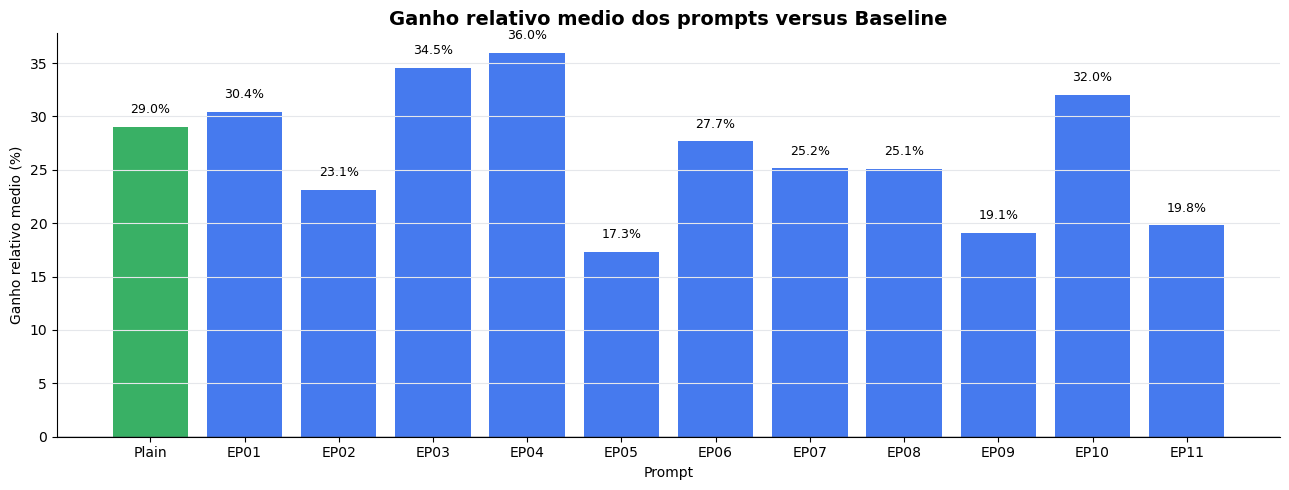

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

plot_data = relative_gain_baseline_summary.reset_index().rename(columns={"Prompt": "Prompt_Label"})
bar_colors = []
for _, row in plot_data.iterrows():
    if row["Prompt_Label"] == "Plain":
        bar_colors.append(COLORS["plain"])
    elif row["mean_relative_gain"] < 0:
        bar_colors.append(COLORS["negative"])
    else:
        bar_colors.append(COLORS["ep"])

ax.bar(plot_data["Prompt_Label"], plot_data["mean_relative_gain"], color=bar_colors, alpha=0.85)
ax.axhline(0, color=COLORS["text"], linewidth=1)
ax.set_title("Ganho relativo medio dos prompts versus Baseline", fontsize=14, weight="bold")
ax.set_xlabel("Prompt")
ax.set_ylabel("Ganho relativo medio (%)")
ax.grid(axis="y", color=COLORS["grid"], linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for index, row in plot_data.iterrows():
    value = row["mean_relative_gain"]
    if pd.notna(value):
        va = "bottom" if value >= 0 else "top"
        offset = 1.0 if value >= 0 else -1.0
        ax.text(index, value + offset, f"{value:.1f}%", ha="center", va=va, fontsize=9)

plt.tight_layout()
plt.show()


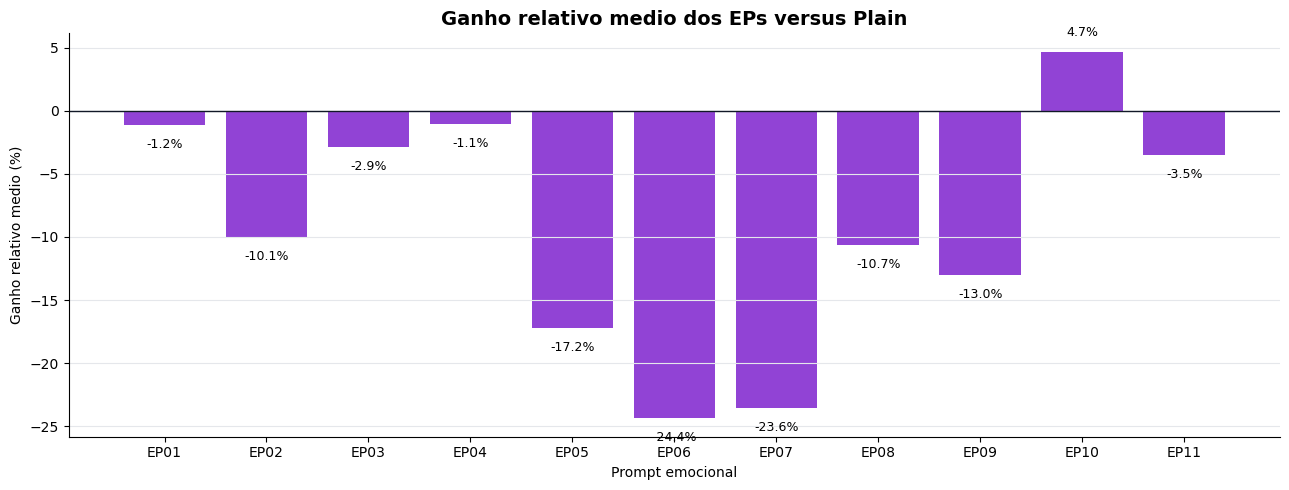

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

plot_data = relative_gain_plain_summary.reset_index().rename(columns={"Prompt": "EP"})

ax.bar(plot_data["EP"], plot_data["mean_relative_gain"], color=COLORS["purple"], alpha=0.85)
ax.axhline(0, color=COLORS["text"], linewidth=1)
ax.set_title("Ganho relativo medio dos EPs versus Plain", fontsize=14, weight="bold")
ax.set_xlabel("Prompt emocional")
ax.set_ylabel("Ganho relativo medio (%)")
ax.grid(axis="y", color=COLORS["grid"], linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for index, row in plot_data.iterrows():
    value = row["mean_relative_gain"]
    if pd.notna(value):
        va = "bottom" if value >= 0 else "top"
        offset = 1.0 if value >= 0 else -1.0
        ax.text(index, value + offset, f"{value:.1f}%", ha="center", va=va, fontsize=9)

plt.tight_layout()
plt.show()


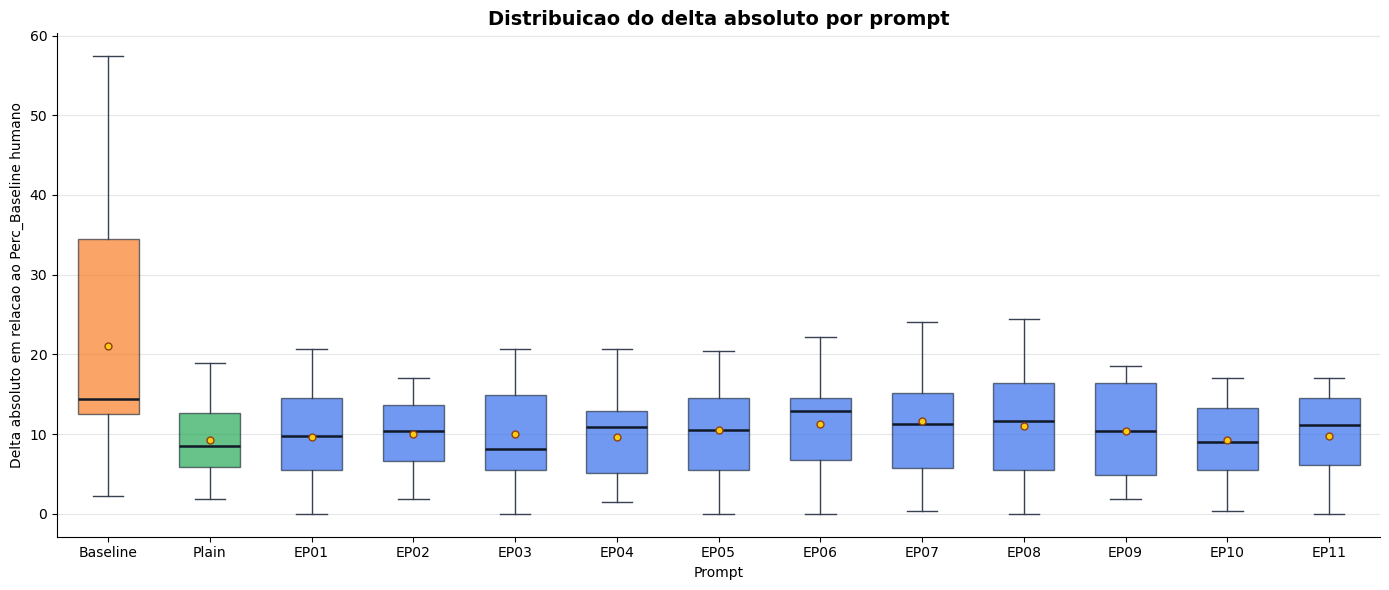

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

box_values = [
    results_aggregated.loc[results_aggregated["Prompt"] == prompt, "Delta_Absolute"].dropna().to_numpy()
    for prompt in PLOT_ORDER
]

boxplot = ax.boxplot(
    box_values,
    tick_labels=PLOT_ORDER,
    patch_artist=True,
    showmeans=True,
    widths=0.6,
    meanprops={"marker": "o", "markerfacecolor": "#FACC15", "markeredgecolor": "#92400E", "markersize": 5},
    medianprops={"color": COLORS["text"], "linewidth": 1.8},
    whiskerprops={"color": "#374151"},
    capprops={"color": "#374151"},
)

for index, box in enumerate(boxplot["boxes"]):
    prompt = PLOT_ORDER[index]
    if prompt == "Baseline":
        color = COLORS["baseline"]
    elif prompt == "Plain":
        color = COLORS["plain"]
    else:
        color = COLORS["ep"]
    box.set_facecolor(color)
    box.set_alpha(0.65)
    box.set_edgecolor("#1F2937")

ax.set_title("Distribuicao do delta absoluto por prompt", fontsize=14, weight="bold")
ax.set_xlabel("Prompt")
ax.set_ylabel("Delta absoluto em relacao ao Perc_Baseline humano")
ax.grid(axis="y", color=COLORS["grid"], linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
